## Introduction

This analysis explores the relationship between market sentiment (Fear/Greed) and trader performance on Hyperliquid.

Objective:
- Analyze how sentiment affects profitability and behavior
- Identify trading patterns
- Propose actionable strategies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

- Loaded sentiment and trading datasets
- Checked missing values and duplicates
- Converted timestamps to date format
- Merged both datasets on date

In [23]:
# Load datasets

Sentiment = pd.read_csv("C:/fear_greed_index.csv")
Historical_Trader = pd.read_csv("C:/historical_data.csv")

In [44]:
# --- SENTIMENT DATA ---

print("Sentiment Shape:",Sentiment.shape)
print("\nSentiment Info:")
print(Sentiment.info())

print("\nSentiment Missing Values:")
print(Sentiment.isnull().sum()) 

print("\n\nSentiment Duplicates:",Sentiment.duplicated().sum())

# ---- Historical_Trader ----

print("\nHistorical_Trader Shape:",Historical_Trader.shape)
print("\nHistorical_Trader Info:")
print(Historical_Trader.info())

print("\nHistorical_Trader Missing Values:")
print(Historical_Trader.isnull().sum())

print("\n\nHistorical_Trader Duplicates:",Historical_Trader.duplicated().sum())


Sentiment Shape: (2644, 4)

Sentiment Info:
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   str   
 3   date            2644 non-null   object
dtypes: int64(2), object(1), str(1)
memory usage: 82.8+ KB
None

Sentiment Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64


Sentiment Duplicates: 0

Historical_Trader Shape: (211224, 17)

Historical_Trader Info:
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2 

# Sentiment dataset contains 2644 rows and 4 columns.
# Trade dataset contains 211,224 rows and 16 columns.
# No major missing values.
# No duplicates.

In [40]:
# Convert epoch timestamp → date
Sentiment['date'] = pd.to_datetime(Sentiment['timestamp'],unit='s').dt.date

In [42]:
Historical_Trader['Timestamp IST'] = pd.to_datetime(Historical_Trader['Timestamp IST'],dayfirst=True)
Historical_Trader['date'] = Historical_Trader['Timestamp IST'].dt.date

In [45]:
Historical_Trader.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [46]:
Sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   str   
 3   date            2644 non-null   object
dtypes: int64(2), object(1), str(1)
memory usage: 82.8+ KB


In [47]:
df = Historical_Trader.merge(
    Sentiment[['date','classification']],
    on='date',
    how='left'
)

In [49]:
print(df.head())

# Check missing sentiment
print("missing sentiment rows:",df['classification'].isnull().sum())

# Check distribution
print(df['classification'].value_counts())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

# The datasets were successfully merged on the date column.
# Only 6 records had missing sentiment values, which is negligible compared to the dataset size.
# The sentiment data includes multiple categories such as Fear, Greed, Extreme Fear, 
# Extreme Greed, and Neutral, allowing for more detailed analysis.

In [ ]:
# Part B — Analysis

In [50]:
#  Rename for easy use

df.rename(columns={
    'Closed PnL':'pnl',
    'Account':'account',
    'Side':'side',
    'Size USD':'size_usd',
    'classification':'sentiment'
},inplace=True)
          

In [ ]:
## Feature Engineering

Created key metrics:
- Daily PnL per trader
- Win rate
- Trade size (USD)
- Trade frequency
- Long/Short distribution

Note:
Leverage data was not available, so trade size is used as a proxy for risk exposure.

In [62]:
# 1. Daily PnL per trader

daily_pnl = df.groupby(['account','date'])['pnl'].sum().reset_index()

In [53]:
# 2. Win rate

df['win'] = df['pnl'] > 0

In [55]:
# 3. Trades per day

trades_per_day = df.groupby('date').size()

In [59]:
# 4. Average trade size

avg_trade_size = df.groupby('sentiment')['size_usd'].mean()

In [67]:
avg_trade_size

sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

# 5.Leverage distribution
# The dataset does not contain explicit leverage information.
# Therefore, leverage distribution could not be directly analyzed.
# Instead, trade size (USD) is used as a proxy for trading intensity.
# Trade size distribution (as a proxy for risk exposure)

In [60]:
# 6. Long / Short ratio

long_short = df.groupby(['sentiment','side']).size().unstack()

## Performance Analysis (PnL & Win Rate)

We analyze how trader performance varies across sentiment categories.

In [73]:
pnl_sentiment = df.groupby('sentiment')['pnl'].mean()
win_rate = df.groupby('sentiment')['win'].mean()

print("PnL:\n", pnl_sentiment)
print("\nWin Rate:\n", win_rate)

PnL:
 sentiment
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: pnl, dtype: float64

Win Rate:
 sentiment
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


 Insight 1: PnL is highest during Extreme Greed (~67.9) and lowest during Neutral/Extreme Fear (~34).

Insight 2: Win rate is highest in Extreme Greed (~46%), showing better trade success in bullish markets.

Insight 3: Fear shows relatively high PnL (~54) despite moderate win rate (~42%), indicating higher risk–reward trades.

Overall, traders perform better in strong positive sentiment compared to neutral or fear conditions.

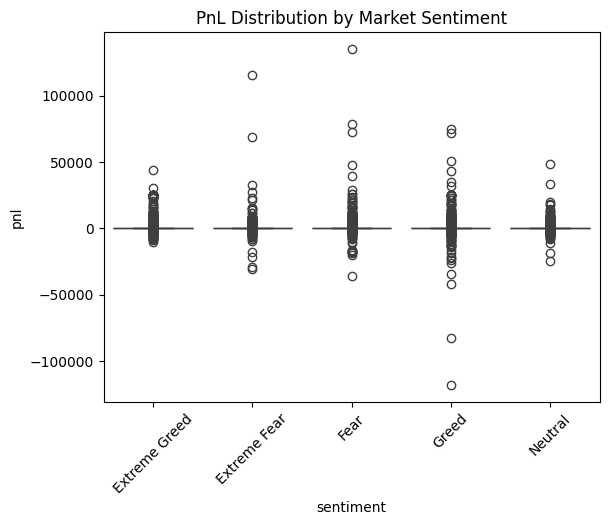

In [68]:
# PnL vs Sentiment

sns.boxplot(x='sentiment',y='pnl',data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

Insight 1: PnL shows high variability across all sentiment types, indicating volatile trading outcomes.

Insight 2: Greed and Fear phases have larger spread and extreme values, suggesting higher risk and reward opportunities.

Insight 3: Extreme positive and negative outliers are present, meaning a few trades contribute significantly to overall PnL.

Most trades cluster near zero PnL, indicating that only a small number of trades drive major profits or losses.

## Behavioral Analysis

We analyze how trader behavior changes based on sentiment:
- Trade size
- Trade frequency
- Long vs Short positions

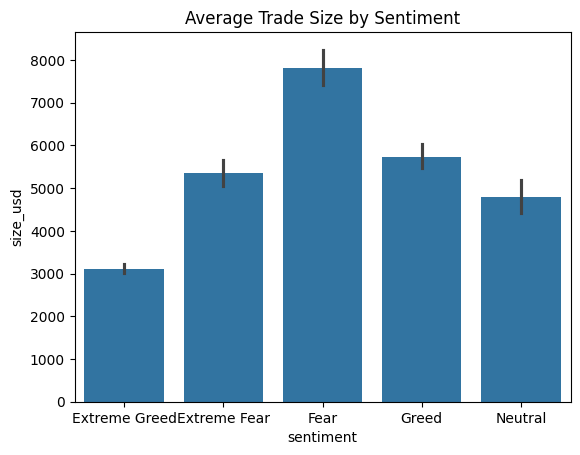

In [70]:
# Trade Size vs Sentiment

sns.barplot(x='sentiment',y='size_usd',data=df)
plt.title("Average Trade Size by Sentiment")
plt.show()

Insight 1: Traders take the largest positions during Fear (~7800 USD), indicating higher risk-taking in bearish markets.

Insight 2: Trade size decreases in Greed (~5700 USD) and is lowest in Extreme Greed (~3100 USD), showing more cautious behavior despite positive sentiment.

Insight 3: This pattern suggests traders may be trying to recover losses during Fear by increasing position size.

Overall, risk-taking behavior is higher in negative sentiment compared to positive sentiment.

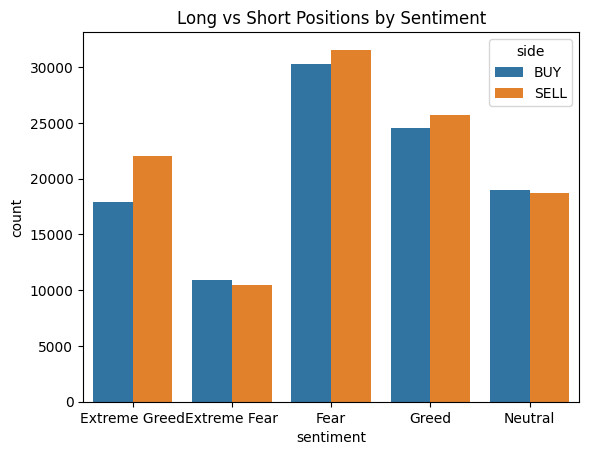

In [84]:
# Long vs Short

sns.countplot(x='sentiment',hue='side',data=df)
plt.title("Long vs Short Positions by Sentiment")
plt.show()

Insight 1: SELL trades slightly dominate BUY trades in most sentiment conditions, especially during Fear and Greed.

Insight 2: During Extreme Fear, BUY and SELL are nearly balanced, indicating uncertainty in trader direction.

Insight 3: Even in Greed and Extreme Greed, SELL remains high, suggesting profit booking or short positioning.

Overall, traders show a slight sell bias across sentiments, rather than a strong directional shift.

## Segmentation Analysis

Traders were segmented based on:
- Trading frequency (Frequent vs Infrequent)
- Trade size (proxy for risk)

This helps identify behavioral differences across trader groups.

In [74]:
trade_counts = df.groupby('account').size()

threshold = trade_counts.median()

df['trader_type'] = df['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

In [75]:
df.groupby(['sentiment','trader_type'])['pnl'].mean()

sentiment      trader_type
Extreme Fear   Frequent        34.163353
               Infrequent      35.941979
Extreme Greed  Frequent        62.870911
               Infrequent     103.264685
Fear           Frequent        51.323784
               Infrequent      80.835791
Greed          Frequent        25.004641
               Infrequent     210.210287
Neutral        Frequent        34.579701
               Infrequent      31.845656
Name: pnl, dtype: float64

Insight 1: Infrequent traders outperform frequent traders in most sentiment conditions, especially during Greed (~210 PnL) and Extreme Greed (~103 PnL).

Insight 2: Frequent traders show more stable but lower returns, while infrequent traders achieve higher but more volatile profits.

Insight 3: During Neutral sentiment, both groups perform similarly, indicating limited trading advantage in sideways markets.

This suggests that selective trading (infrequent) may be more profitable than overtrading.

In [ ]:
# Part C — “Actionable output” 

Strategy 1: During Fear periods, traders should reduce position size, as larger trades are associated with higher risk and volatility with inconsistent win rates.

Strategy 2: During Extreme Greed, traders can increase participation, as both PnL (~67.9) and win rate (~46%) are highest in strong bullish conditions.

Strategy 3 (based on segmentation): Infrequent traders outperform frequent traders, especially in Greed phases.
→ Focus on selective, high-quality trades instead of overtrading.

In [79]:
import sys
print(sys.executable)

C:\Users\vipul\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [80]:
import sklearn
print(sklearn.__version__)

1.8.0


In [81]:
from sklearn.cluster import KMeans

## Clustering Analysis (Bonus)

KMeans clustering was used to group traders based on:
- PnL
- Trade size

This helps identify different trading archetypes.

In [82]:

from sklearn.cluster import KMeans

X = df[['pnl','size_usd']].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

print(df['cluster'].value_counts())

cluster
0    210081
1      1122
2        21
Name: count, dtype: int64


In [83]:
df.groupby('cluster')[['pnl','size_usd']].mean()

,pnl,size_usd
cluster,,
0,42.604378,3.923889e+03
1,1132.724766,2.826782e+05
2,3603.404334,2.366092e+06


Insight 1: Cluster 0 represents the majority of traders with low PnL (~42) and small trade sizes (~3.9K USD), indicating typical low-risk behavior.

Insight 2: Cluster 1 includes traders with higher PnL (~1132) and significantly larger trade sizes (~282K USD), suggesting medium-to-high risk strategies.

Insight 3: Cluster 2 consists of a very small group of traders with extremely high PnL (~3603) and very large trade sizes (~2.36M USD), representing high-risk, high-reward trading behavior.

This shows that a small group of traders taking larger positions tends to generate disproportionately higher returns, highlighting the impact of risk exposure on profitability.

## Strategy Recommendations

1. Reduce position size during Fear to manage risk and volatility.

2. Increase trading activity during Extreme Greed to benefit from favorable conditions.

3. Avoid overtrading — focus on selective trades, as infrequent traders show higher profitability.

## Conclusion

Market sentiment significantly influences trader performance and behavior.

Aligning trading strategies with sentiment and avoiding excessive risk can improve profitability.